# Notes
* 2025-03-20 updates
    * Chose fixed chunking with 250 words
        * SentenceTransformer model is limited to 384 tokens
        * Recursive chunker does not correctly return the split information (split overlap, source ID, page number)
    * Current tagging strategy
        * Ask LLM for one tag per chunk. Prompt v10 seems pretty good - go over prompt.
        * For each document, track the tagged and untagged chunks. Tags that show up in >= 30% (hyperparameter) of tagged chunks will be stored in a list. All tagged chunks will be tagged with this list.
        * Untagged chunks will be discarded
    * Current evaluation strategy
        * One label per chunk
        * Two metrics: found_label (recall), and number of tags (precision?)
    * Potential tagging strategy
        * Ask LLM for multiple tags per chunk. Prompt with example topics that fall into multiple categories, like how data cleaning can fall under both data science and data engineering, or how containerization can fall under both MLOps (MLE) and Infrastructure and Operations.
        * Otherwise, same as current strategy
    * Potential evaluation strategy
        * Multiple labels per chunk
        * Two metrics: recall, Jaccard similarity, precision?
* 2025-03-26 updates
    * PPTX conversion - actually, seems to work well for the most part (content is generally after title in the conversion, except for one exception)
* Next steps
    * Multi-label tagging + validation datasets to evaluate generalization. Could run directly on other format types to evaluate generalization (fine-tune on PPTX, apply to other formats).
        * V12 seems better than V13 except for hallucinating SQL as a category. Do we even need to specify tags for SQL? (Or Python?)
        * V14 - not including SQL as an example topic means that some of the Metabase slides are untagged
        * V14 (multi-label) vs. V10 (single-label)
            * V14 does not do as well on Metabase slides (this may be improved by including the title in the chunk)
            * But I think in general that multi-label tagging is the way to go
        * Ask LLM for label + confidence score before manual labeling
        * LLM output validation: hallucinate tags, hallucinate format
    * MLflow for experiment tracking

* Prompting from other team (job descriptions)
* Can you ask the LLM to return an empty list if there's not much info in the chunk?
* You could include the document title to help
* Should I have a different pipeline where I prompt the LLM for their reasoning on the tagging? RAG pipeline. But temperature will be different? Can you use 0 for RAG?
* OCR for images?

# Download files

In [1]:
import sys
from dotenv import load_dotenv
import os

load_dotenv(override=True)

if "../app/" not in sys.path:
    sys.path.append("../app/")

print(sys.path)

['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/ryanwtsai/repos/lms-ai-agent/app/venv/lib/python3.12/site-packages', '../app/']


In [48]:
import boto3, re

s3_client = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_REGION"),
)

In [49]:
bucket_name = "content-tagging-lms"

files = [d["Key"] for d in s3_client.list_objects(Bucket=bucket_name)["Contents"] if re.search(".pptx", d["Key"])]

for file in files:
    print(file)

# for file in files:
#     print(file)
#     head, _ = os.path.split(file)
#     print(head)
#     os.makedirs(head, exist_ok=True)
#     s3_client.download_file(bucket_name, file, file)

Content/AWS introduction/AWS VPC & Networking.pptx
Content/AWS introduction/Introduction to AWS.pptx
Content/AWS introduction/Introduction to Cloud.pptx
Content/AWS introduction/Introduction to EC2.pptx
Content/AWS introduction/Introduction to S3.pptx
Content/AWS introduction/RDS-Lecture.pptx
Content/Data Visualization/4.2-Introduction to Metabase (BI).pptx
Content/Large Language Model ( LLM)/Part_10_LLM_Use_Cases-20250225T182513Z-001/Part_10_LLM_Use_Cases/Copy of 10.2 Search Engine.pptx
Content/Large Language Model ( LLM)/Part_10_LLM_Use_Cases-20250225T182513Z-001/Part_10_LLM_Use_Cases/Copy of 10.3 Summary.pptx
Content/Large Language Model ( LLM)/Part_10_LLM_Use_Cases-20250225T182513Z-001/Part_10_LLM_Use_Cases/Time_Series/Copy of m3.1-data-prep-timeseries-lecture.pptx
Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Annotation/Lecture_LLM_Data_Labelling.pptx
Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Collection/Lecture_LLM_Data_Collection.pptx
Con

# Use pipeline to chunk

In [87]:
# collection_name = "pptx_fixed250_tag30_prompt10"
collection_name = "pptx_fixed250_tag30_prompt14"

In [88]:
from haystack_utilities.pipelines import build_indexing_pipeline

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 100,
    "split_overlap": 20,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 200,
    "split_overlap": 40,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 300,
    "split_overlap": 60,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "fixed",
    "split_by": "word",
    "split_length": 300,
    "split_overlap": 60,
    "split_threshold": 300,
    "respect_sentence_boundary": True
}

splitting_options = {
    "split_strategy": "fixed",
    "split_by": "word",
    "split_length": 500,
    "split_overlap": 100,
    "split_threshold": 500,
    "respect_sentence_boundary": True
}

# sentence-transformers/all-mpnet-base-v2
# Max tokens = 384
# Roughly 288 words (3 words = 4 tokens)
# 'fixed250'
splitting_options = {
    "split_strategy": "fixed",
    "split_by": "word",
    "split_length": 250,
    "split_overlap": 50,
    "split_threshold": 30,
    "respect_sentence_boundary": True
}

index_pipe = build_indexing_pipeline(collection_name, splitting_options, file_extension=".pptx", max_content_len_chars=65535, drop_old=True)
# index_pipe = build_indexing_pipeline(collection_name, splitting_options, file_extension=".pptx", max_content_len_chars=65535, drop_old=False)

Some secret values are not encrypted. Please use `Secret` class to encrypt them. The best way to implement it is to use `Secret.from_env` to load from environment variables. For example:
from haystack.utils import Secret
token = Secret.from_env('YOUR_TOKEN_ENV_VAR_NAME')


In [ ]:
# from haystack.utils import Secret

# print(Secret.from_env_var("ZILLIZ_CLUSTER_ENDPOINT").resolve_value())
# print(Secret.from_env_var("ZILLIZ_CLUSTER_TOKEN").resolve_value())

https://in03-16554725d13526b.serverless.gcp-us-west1.cloud.zilliz.com
a9184930ba876ffbfd87a0d8b194e6e8b1f8d9308593597b3e35eb6df26c7c70299ec5ca6b52d7c71a82b3302f6730387f69cba7


In [89]:
fnames = ["Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Annotation/Lecture_LLM_Data_Labelling.pptx"]
# fnames = ["Content/AWS introduction/Introduction to AWS.pptx"]
# fnames = ["Content/Data Visualization/4.2-Introduction to Metabase (BI).pptx"]
fnames = ["Content/Large Language Model ( LLM)/Part_9_RAG-20250225T182503Z-001/Part_9_RAG/Lecture_RAG_Introduction.pptx", "Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Annotation/Lecture_LLM_Data_Labelling.pptx"]
fnames = ["Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Collection/Lecture_LLM_Data_Collection.pptx", "Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Preparation/Lecture_LLM_Data_Preparation.pptx"]
fnames = ["Content/Large Language Model ( LLM)/Part_10_LLM_Use_Cases-20250225T182513Z-001/Part_10_LLM_Use_Cases/Time_Series/Copy of m3.1-data-prep-timeseries-lecture.pptx"]
fnames = files

index_results = index_pipe.run({"converter": {"sources": fnames}}, include_outputs_from={"converter", "cleaner", "splitter"})
# results = index_pipe.run({"converter": {"sources": fnames}}, include_outputs_from={"converter", "splitter"})
index_results

No abbreviations file found for en. Using default abbreviations.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

{'writer': {'documents_written': 154},
 'converter': {'documents': [Document(id=6209a6c091b8886dc1e125aa9831099ef15f9ce2432d2b5c59829f72a012eee9, content: 'AWS VPC & Networking
   
   References
   https://www.slideshare.net/slideshow/aws-vpc-257494024/257494024#53...', meta: {'file_path': 'AWS VPC & Networking.pptx'}),
   Document(id=61bd474207f6b52592d67a5f70675479b4160e93df31e57c7b7a6bd4de653d51, content: 'Introduction to 
   Amazon Web Services
    Prepared by WeCloudData
   Agenda.
   AWS v.s. Others
   Companies on A...', meta: {'file_path': 'Introduction to AWS.pptx'}),
   Document(id=fd046b6585628844a58a69049521b810484a93fb776a727b546886fd673f56c1, content: 'Introduction to Cloud Computing
    Prepared by WeCloudData
   Agenda.
   What is Cloud? 
   Types of Cloud
   Type...', meta: {'file_path': 'Introduction to Cloud.pptx'}),
   Document(id=96cf0bd521f03de0069baf5031dde61c0914941a1625bfadd68500786429d751, content: 'Working with EC2
    Prepared by WeCloudData
   Agenda.
   Wh

In [8]:
if "splitter" in index_results.keys():
    lengths = [len(doc.content) for doc in index_results["splitter"]["documents"]]
    print(f"Max len char = {max(lengths)}")
    print(f"Min len char = {min(lengths)}")

Max len char = 2807
Min len char = 203


(array([1., 0., 0., 0., 0., 0., 1., 0., 0., 2.]),
 array([1182. , 1258.2, 1334.4, 1410.6, 1486.8, 1563. , 1639.2, 1715.4,
        1791.6, 1867.8, 1944. ]),
 <BarContainer object of 10 artists>)

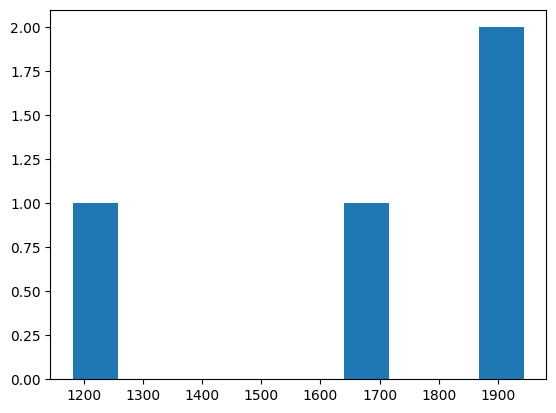

In [9]:
import matplotlib.pyplot as plt

plt.hist(lengths)

In [10]:
if not os.path.exists("./experiments"):
    os.mkdir("./experiments")

component_names = ["converter", "cleaner"]

for name in component_names:
    if name in index_results.keys():
        fname = f"./experiments/{name}_output.txt"
        with open(fname, "w") as file:
            file.write(index_results[name]["documents"][0].content)
            print(f"{fname} written.")


component_names = ["splitter"]

for name in component_names:
    if name in index_results.keys():
        fname = f"./experiments/{name}_output.txt"

        if os.path.exists(fname):
            os.remove(fname)

        with open(f"./experiments/{name}_output.txt", "a") as file:
            for doc in index_results[name]["documents"]:
                file.write(f"{doc.content}\n{"-"*200}\n")
            print(f"{fname} written.")

./experiments/converter_output.txt written.
./experiments/cleaner_output.txt written.
./experiments/splitter_output.txt written.


# Use pipeline to tag

In [63]:
from haystack_utilities.pipelines import build_tagging_pipeline

# V11 - multi-label tagging
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Data Analysis, Data Engineering, Data Science, Infrastructure and Operations, Machine Learning Engineering].

    I will give you a text chunk, delimited in triple backticks, and you will identify all applicable tags based on the text chunk.
    
    Please format the tags as a Python list of strings, e.g. ["Machine Learning Engineering", "Data Science"].
    
    Respond only with the list, no other text. If none of the tags apply, respond with an empty list, [].

    Here are my guidelines for how to decide which tag to choose.
    * Anything related to processing data before modeling or analysis, e.g. collecting, ingesting, cleaning, normalizing, and moving data, should be tagged as ["Data Engineering", "Data Science"].
    * Anything related to database design and data modeling should be tagged as ["Data Engineering", "Data Science"].
    * Very simple data analysis like descriptive, diagnostic, and exploratory analysis, and data visualization should be tagged as ["Data Analysis", "Data Science"].
    * Business intelligence and Excel tutorials should be tagged as ["Data Analysis"].
    * SQL tutorials should be tagged as ["Data Analysis", "Data Engineering", "Data Science", "Machine Learning Engineering"].
    * Inferential data analysis should be tagged as ["Data Science"].
    * Feature engineering should be tagged as ["Data Science"].
    * Predictive and prescriptive data analysis should be tagged as ["Data Science", "Machine Learning Engineering"].
    * Statistical modeling techniques like linear regression, logistic regression, decision trees, SVM, etc. should be tagged as ["Data Science", "Machine Learning Engineering"].
    * Data labeling/annotation, both manual and with the help of LLMs, should be tagged as ["Data Science", "Machine Learning Engineering"].
    * Traditional NLP techniques like TF-IDF, BM25, bag-of-words should be tagged as ["Data Science", "Machine Learning Engineering"].
    * Anything related to deep learning, including neural networks, modern computer vision, modern NLP, large language models, and AI should be tagged as ["Data Science", "Machine Learning Engineering"].
    * Anything related to retrieval-augmented generation (RAG), like vector indexing and vector search, should be tagged as ["Data Science", "Machine Learning Engineering"].
    * Anything related to information retrieval and search engines should be tagged as ["Data Science", "Machine Learning Engineering"].
    * Anything related to deployment, operations, and scaling, including DevOps, CI/CD, cloud computing, computer networking, distributed computing, and containerization, should be tagged as ["Infrastructure and Operations"].
    * Anything related to MLOps, model deployment, and model monitoring should be tagged as ["Infrastructure and Operations", "Machine Learning Engineering"].

    Text chunk: ```{{doc.content}}```
    """

# V12
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: Data Analysis, Data Engineering, Data Science, Infrastructure and Operations, Machine Learning Engineering.

    I will give you a text chunk, delimited in triple backticks, and you will identify all applicable tags based on the text chunk.
    
    Please format the tags as a Python list of strings. Respond only with the list, no other text, e.g. ["Machine Learning Engineering", "Data Science"].
    
    If none of the tags apply, respond with an empty list, [].

    Here are my guidelines for how to decide which tags to choose. I will give a topic followed by the recommended tags.
    * Anything related to processing data before modeling or analysis, e.g. collecting, ingesting, cleaning, normalizing, and moving data: ["Data Engineering", "Data Science"].
    * Anything related to database design and data modeling: ["Data Engineering", "Data Science"].
    * Very simple data analysis like descriptive, diagnostic, and exploratory analysis, and data visualization: ["Data Analysis", "Data Science"].
    * Business intelligence and Excel tutorials: ["Data Analysis"].
    * SQL tutorials: ["Data Analysis", "Data Engineering", "Data Science", "Machine Learning Engineering"].
    * Inferential data analysis: ["Data Science"].
    * Feature engineering: ["Data Science"].
    * Predictive and prescriptive data analysis: ["Data Science", "Machine Learning Engineering"].
    * Statistical modeling techniques like linear regression, logistic regression, decision trees, SVM, etc.: ["Data Science", "Machine Learning Engineering"].
    * Data labeling/annotation, both manual and with the help of LLMs: ["Data Science", "Machine Learning Engineering"].
    * Traditional NLP techniques like TF-IDF, BM25, bag-of-words: ["Data Science", "Machine Learning Engineering"].
    * Anything related to deep learning, including neural networks, modern computer vision, modern NLP, large language models, and AI: ["Data Science", "Machine Learning Engineering"].
    * Anything related to retrieval-augmented generation (RAG), like vector indexing and vector search: ["Data Science", "Machine Learning Engineering"].
    * Anything related to information retrieval and search engines: ["Data Science", "Machine Learning Engineering"].
    * Anything related to deployment, operations, and scaling, including DevOps, CI/CD, cloud computing, computer networking, distributed computing, and containerization: ["Infrastructure and Operations"].
    * Anything related to MLOps, model deployment, and model monitoring: ["Infrastructure and Operations", "Machine Learning Engineering"].

    Text chunk: ```{{doc.content}}```
    """

# V13
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    I will give you a text chunk, delimited in triple backticks, and you will identify all applicable tags based on the text chunk. You can only pick tags from this list: Data Analysis, Data Engineering, Data Science, Infrastructure and Operations, Machine Learning Engineering.
    
    Please format the tags as a Python list of strings. Respond only with the list, no other text, e.g. ["Machine Learning Engineering", "Data Science"].
    
    If none of the tags apply, respond with an empty list, [].

    Here are my guidelines for how to decide which tags to choose. Carefully consider all guidelines before choosing the tags.
    * ["Data Engineering", "Data Science"]: Anything related to processing data before modeling or analysis, e.g. collecting, ingesting, cleaning, normalizing, and moving data. Anything related to database design and data modeling.
    * ["Data Analysis", "Data Science"]: Very simple data analysis like descriptive, diagnostic, and exploratory analysis, and any kind of data visualization, like dashboards.
    * ["Data Analysis"]: Business intelligence and Excel tutorials.
    * ["Data Analysis", "Data Engineering", "Data Science", "Machine Learning Engineering"]: SQL tutorials.
    * ["Data Science"]: Inferential data analysis. Feature engineering. Data labeling/annotation, both manual and with the help of LLMs.
    * ["Data Science", "Machine Learning Engineering"]: Predictive and prescriptive data analysis. Statistical modeling techniques like linear regression, logistic regression, decision trees, SVM, etc. Traditional NLP techniques like TF-IDF, BM25, bag-of-words. Anything related to deep learning, including neural networks, modern computer vision, modern NLP, large language models, AI, information retrieval and search engines. Anything related to retrieval-augmented generation (RAG), like vector indexing and vector search.
    * ["Infrastructure and Operations"]: Anything related to deployment, operations, and scaling, including DevOps, CI/CD, cloud computing, computer networking, distributed computing, and containerization.
    * ["Infrastructure and Operations", "Machine Learning Engineering"]: Anything related to MLOps, model deployment, and model monitoring.

    Text chunk: ```{{doc.content}}```
    """

# V14 - iterating from V12
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    I will give you a text chunk, delimited in triple backticks, and you will identify all applicable tags based on the text chunk. You can only pick tags from this list: Data Analysis, Data Engineering, Data Science, Infrastructure and Operations, Machine Learning Engineering.
    
    Please format the tags as a Python list of strings. Respond only with the list, no other text, e.g. ["Machine Learning Engineering", "Data Science"].
    
    If none of the tags apply, respond with an empty list, [].

    Here are my guidelines for how to decide which tags to choose. I will give a topic followed by the recommended tags.
    * Anything related to processing data before modeling or analysis, e.g. collecting, ingesting, cleaning, normalizing, and moving data: ["Data Engineering", "Data Science"].
    * Anything related to database design and data modeling: ["Data Engineering", "Data Science"].
    * Very simple data analysis like descriptive, diagnostic, and exploratory analysis, and data visualization: ["Data Analysis", "Data Science"].
    * Business intelligence and Excel tutorials: ["Data Analysis"].
    * Inferential data analysis: ["Data Science"].
    * Feature engineering: ["Data Science"].
    * Predictive and prescriptive data analysis: ["Data Science", "Machine Learning Engineering"].
    * Statistical modeling techniques like linear regression, logistic regression, decision trees, SVM, etc.: ["Data Science", "Machine Learning Engineering"].
    * Data labeling/annotation, both manual and with the help of LLMs: ["Data Science", "Machine Learning Engineering"].
    * Traditional NLP techniques like TF-IDF, BM25, bag-of-words: ["Data Science", "Machine Learning Engineering"].
    * Anything related to deep learning, including neural networks, modern computer vision, modern NLP, large language models, and AI: ["Data Science", "Machine Learning Engineering"].
    * Anything related to retrieval-augmented generation (RAG), like vector indexing and vector search: ["Data Science", "Machine Learning Engineering"].
    * Anything related to information retrieval and search engines: ["Data Science", "Machine Learning Engineering"].
    * Anything related to deployment, operations, and scaling, including DevOps, CI/CD, cloud computing, computer networking, distributed computing, and containerization: ["Infrastructure and Operations"].
    * Anything related to MLOps, model deployment, and model monitoring: ["Infrastructure and Operations", "Machine Learning Engineering"].

    Text chunk: ```{{doc.content}}```
    """

# # ChatGPT
# prompt_template_tagging = """
#     I am doing a content tagging project. The goal of the project is to tag teaching materials.

#     Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

#     Here are some examples of topics for each tag:
#     * **Machine Learning Engineering:**
#         - Fine-Tuning, Parameter-Efficient Fine-Tuning (PEFT), Low-Rank Adaptation (LoRA)
#         - AI, Generative AI (GenAI), AI Agents
#         - Natural Language Processing (NLP), Large Language Models (LLM), Prompt Engineering
#         - Retrieval-Augmented Generation (RAG), Vector Databases, Vector Search, Chunking
#         - Computer Vision, Object Detection, Image Classification
#     * **Data Science:**
#         - Statistical Modeling, Statistical Analysis, Hypothesis Testing
#         - Feature Engineering, Data Transformation
#         - Classic Information Retrieval, BM25, TF-IDF, Bag of Words
#         - Machine Learning Algorithms (e.g., Regression, Classification)
#     * **Data Analysis:**
#         - Business Intelligence (BI), Reporting
#         - SQL, Excel, Data Querying
#         - Exploratory Data Analysis (EDA), Descriptive Statistics
#         - Data Visualization (e.g., Tableau, Power BI)
#     * **Data Engineering:**
#         - ETL (Extract, Transform, Load), Data Pipelines, Data Collection, Data Cleaning
#         - Big Data Technologies: Spark, Hadoop, Kafka
#         - Data Storage (Databases, Data Lakes, Warehouses)
#         - Web Scraping, Data Wrangling
#     * **Infrastructure and Operations:**
#         - MLOps, Model Deployment, Model Monitoring
#         - DevOps, CI/CD (Continuous Integration/Continuous Delivery)
#         - Cloud Platforms: AWS, GCP, Azure
#         - Distributed Systems, Load Balancing
#         - Networking, VPNs, Cloud Networking

#     I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

#     Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
#     Respond only with the list, no other text.

#     If none of the tags apply, respond with an empty list, [].

#     Text chunk: ```{{doc.content}}```
#     """

tag_pipe = build_tagging_pipeline(collection_name, prompt_template_tagging)

Some secret values are not encrypted. Please use `Secret` class to encrypt them. The best way to implement it is to use `Secret.from_env` to load from environment variables. For example:
from haystack.utils import Secret
token = Secret.from_env('YOUR_TOKEN_ENV_VAR_NAME')


In [64]:
prompt_template_tagging

'\n    I am doing a content tagging project. The goal of the project is to tag teaching materials.\n\n    I will give you a text chunk, delimited in triple backticks, and you will identify all applicable tags based on the text chunk. You can only pick tags from this list: Data Analysis, Data Engineering, Data Science, Infrastructure and Operations, Machine Learning Engineering.\n    \n    Please format the tags as a Python list of strings. Respond only with the list, no other text, e.g. ["Machine Learning Engineering", "Data Science"].\n    \n    If none of the tags apply, respond with an empty list, [].\n\n    Here are my guidelines for how to decide which tags to choose. I will give a topic followed by the recommended tags.\n    * Anything related to processing data before modeling or analysis, e.g. collecting, ingesting, cleaning, normalizing, and moving data: ["Data Engineering", "Data Science"].\n    * Anything related to database design and data modeling: ["Data Engineering", "Da

In [65]:
tag_results = tag_pipe.run({})

tag_results

{'upserter': {'documents_written': 154}}

# Check tagging results

In [66]:
from pymilvus import MilvusClient
import os
from dotenv import load_dotenv

load_dotenv(override=True)

client = MilvusClient(
    uri=os.getenv("ZILLIZ_CLUSTER_ENDPOINT"),
    token=os.getenv("ZILLIZ_CLUSTER_TOKEN")
)

In [67]:
tags = ["Machine Learning Engineering", "Data Analysis", "Data Engineering", "Data Science", "Infrastructure and Operations", "Other"]
# fname = 'Introduction to AWS.pptx'
# fname = "4.2-Introduction to Metabase (BI).pptx"

for tdx, tag in enumerate(tags):
    filter = f"json_contains(metadata['tags'], '{tag}')"
    # filter = f"json_contains(metadata['tags'], '{tag}') AND metadata['title'] == '{fname}'"
    res = client.query(
        collection_name=collection_name,
        filter=filter,
        output_fields=["text", "metadata"],
    )
    
    n_chunks = len(res)
    print(f"{tag}: {n_chunks}")

    # if os.path.exists(f"./experiments/tagged_chunks_{tdx}.txt"):
    #     os.remove(f"./experiments/tagged_chunks_{tdx}.txt")
    
    # with open(f"./experiments/tagged_chunks_{tdx}.txt", "a") as file:
    #     for r in res:
    #         # file.write(f"{r['text']}\n{"-"*100}\n\n")
    #         # file.write(r["metadata"]["title"])
    #         file.write(f"{r['text']}\n\n")
    #         file.write(f"{r['metadata']['title']}\n{"-"*100}\n")

    fname = f"./experiments/tagged_chunks_{tag}_{n_chunks}.txt"
    if os.path.exists(fname):
        os.remove(fname)
    
    with open(fname, "a") as file:
        for r in res:
            # file.write(f"{r['text']}\n{"-"*100}\n\n")
            # file.write(r["metadata"]["title"])
            file.write(f"{r['text']}\n\n")
            file.write(f"{r['metadata']['title']}\n{"-"*100}\n")

Machine Learning Engineering: 112
Data Analysis: 3
Data Engineering: 29
Data Science: 140
Infrastructure and Operations: 8
Other: 0


In [68]:
filter = 'metadata["tags"] == []'
# filter = f"metadata['tags'] == [] AND metadata['title'] == '{fname}'"
res = client.query(
    collection_name=collection_name,
    filter=filter,
    output_fields=["text", "metadata"],
)

n_chunks = len(res)
print(n_chunks)

fname = f"./experiments/untagged_chunks_{n_chunks}.txt"
if os.path.exists(fname):
    os.remove(fname)

with open(fname, "a") as file:
    for r in res:
        file.write(f"{r['text']}\n\n")
        file.write(f"{r['metadata']['title']}\n{"-"*100}\n")

7


In [57]:
lengths = [len(r['text']) for r in res]
print(lengths)

[298, 992, 203, 547, 1321]


# Evaluate tagging accuracy

In [69]:
import pandas as pd
import pickle

# Contains labels
label_file = "df_labels_fixed250.pkl"
df = pd.read_pickle(f"./labeling/pptx/{label_file}")

client = MilvusClient(
    uri=os.getenv("ZILLIZ_CLUSTER_ENDPOINT"),
    token=os.getenv("ZILLIZ_CLUSTER_TOKEN"),
)

df.head(10)

,id,text,filename,label
0,1cb7fea7b70bc34ddca2e79e1b572706606df34c92b767...,Improving security posture by keeping traffic ...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations]
1,4da198d57afd26c5ef328b79f5c5b5e359b05203880f18...,AWS VPC & Networking References\nhttps://www.s...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations]
2,5406e231098fe80ca23265bcc9e897588e072dd7b68565...,Best practices for subnet sizing and availabil...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations]
3,4a85ffea7658fab70f26160859ad8ebed8d2338dc90f48...,RDS\nReference: https://www.slideshare.net/sli...,Content/AWS introduction/RDS-Lecture.pptx,[Infrastructure and Operations]
4,ab26be99457f22c8c78d85b99f0e08854b476b8d083a93...,Introduction to Cloud Computing Prepared by We...,Content/AWS introduction/Introduction to Cloud...,[Infrastructure and Operations]
5,01e7692c1a39a9b9590247b79f7a27bfa5b00b0045124f...,Introduction to S3 Prepared by WeCloudData Age...,Content/AWS introduction/Introduction to S3.pptx,[Infrastructure and Operations]
6,cee6c4d5d43d4ab1574535c3f30372eee810e555aac7f3...,Working with EC2 Prepared by WeCloudData Agend...,Content/AWS introduction/Introduction to EC2.pptx,[Infrastructure and Operations]
7,86ce3078fe121c3e8c4c63a5a4c9df82afc6ac1102e3ee...,Introduction to Amazon Web Services Prepared b...,Content/AWS introduction/Introduction to AWS.pptx,[Infrastructure and Operations]
8,02d77d486cb02c4774ea2ad831d9a188fd445789fb8dd7...,Will properly cleaned web data be enough? Idea...,Content/Large Language Model ( LLM)/Part_3_Dat...,"[Data Engineering, Data Science]"
9,0d34d7f5f362313473b6accb156997c457116fdb98146a...,Idea: frequently used words should not be spli...,Content/Large Language Model ( LLM)/Part_3_Dat...,"[Data Engineering, Data Science]"


In [ ]:
# Single label evaluation

fname_base = f"df_tagged_{re.sub("pptx_", "", collection_name)}"

d = {
    "id": [],
    "filename": [],
    "labels": [],
    "tags": [],
    "found_label": [],
    "number_of_tags": [],
}

for idx in range(len(df)):
    # print(df.loc[idx, "id"])
    res = client.get(
        collection_name=collection_name,
        ids=[df.loc[idx, "id"]],
        output_fields=["id", "metadata"]
    )

    if res == []:
        continue

    tags = res[0]["metadata"]["tags"]
    label = df.loc[idx, "label"][0]
    found_label = True if label in tags else False

    d["id"].append(df.loc[idx, "id"])
    d["filename"].append(df.loc[idx, "filename"])
    d["labels"].append(label)
    d["tags"].append(tags)
    d["found_label"].append(found_label)
    d["number_of_tags"].append(len(tags))

df_out = pd.DataFrame.from_dict(d)
df_out.to_pickle(f"./labeling/pptx/{fname_base}.pkl")
df_out.to_csv(f"./labeling/pptx/{fname_base}.csv")
df_out

,id,filename,labels,tags,found_label,number_of_tags
0,1cb7fea7b70bc34ddca2e79e1b572706606df34c92b767...,Content/AWS introduction/AWS VPC & Networking....,Infrastructure and Operations,[Infrastructure and Operations],True,1
1,4da198d57afd26c5ef328b79f5c5b5e359b05203880f18...,Content/AWS introduction/AWS VPC & Networking....,Infrastructure and Operations,[Infrastructure and Operations],True,1
2,5406e231098fe80ca23265bcc9e897588e072dd7b68565...,Content/AWS introduction/AWS VPC & Networking....,Infrastructure and Operations,[Infrastructure and Operations],True,1
3,4a85ffea7658fab70f26160859ad8ebed8d2338dc90f48...,Content/AWS introduction/RDS-Lecture.pptx,Infrastructure and Operations,[Infrastructure and Operations],True,1
4,ab26be99457f22c8c78d85b99f0e08854b476b8d083a93...,Content/AWS introduction/Introduction to Cloud...,Infrastructure and Operations,[],False,0
...,...,...,...,...,...,...
149,6461aef483d6a5d0c47fda774fed3c7bed1be005bfed04...,Content/Data Visualization/4.2-Introduction to...,Data Analysis,[Data Analysis],True,1
150,6b65da52bf35ae285ba96f9197c0753155fcd4b928578f...,Content/Data Visualization/4.2-Introduction to...,Data Analysis,[Data Analysis],True,1
151,760b7888097cb5a0565ab4fbfef120437bcdb54c8902f1...,Content/Data Visualization/4.2-Introduction to...,Data Analysis,[Data Analysis],True,1
152,a9f0ed0c17f6c8044a5864409282085b18dcbad4e55c4a...,Content/Data Visualization/4.2-Introduction to...,Data Analysis,[Data Analysis],True,1


In [ ]:
# Multilabel evaluation

import re
fname_base = f"df_tagged_{re.sub("pptx_", "", collection_name)}"

d = {
    "id": [],
    "filename": [],
    "labels": [],
    "tags": [],
    "jaccard_similarity": [],
}

for idx in range(len(df)):
    # print(df.loc[idx, "id"])
    res = client.get(
        collection_name=collection_name,
        ids=[df.loc[idx, "id"]],
        output_fields=["id", "metadata"]
    )

    tags = set(res[0]["metadata"]["tags"])
    labels = set(df.loc[idx, "label"])
    intersection = tags.intersection(labels)
    union = tags.union(labels)
    if not union:
        jac_sim = 0
    else:
        jac_sim = len(intersection)/len(union)

    d["id"].append(df.loc[idx, "id"])
    d["filename"].append(df.loc[idx, "filename"])
    d["labels"].append(labels)
    d["tags"].append(tags)
    d["jaccard_similarity"].append(jac_sim)

df_out = pd.DataFrame.from_dict(d)
df_out.to_pickle(f"./labeling/pptx/{fname_base}.pkl")
df_out.to_csv(f"./labeling/pptx/{fname_base}.csv")
df_out

,id,filename,labels,tags,jaccard_similarity
0,1cb7fea7b70bc34ddca2e79e1b572706606df34c92b767...,Content/AWS introduction/AWS VPC & Networking....,{Infrastructure and Operations},{Infrastructure and Operations},1.000000
1,4da198d57afd26c5ef328b79f5c5b5e359b05203880f18...,Content/AWS introduction/AWS VPC & Networking....,{Infrastructure and Operations},{Infrastructure and Operations},1.000000
2,5406e231098fe80ca23265bcc9e897588e072dd7b68565...,Content/AWS introduction/AWS VPC & Networking....,{Infrastructure and Operations},{},0.000000
3,4a85ffea7658fab70f26160859ad8ebed8d2338dc90f48...,Content/AWS introduction/RDS-Lecture.pptx,{Infrastructure and Operations},"{Data Science, Infrastructure and Operations, ...",0.333333
4,ab26be99457f22c8c78d85b99f0e08854b476b8d083a93...,Content/AWS introduction/Introduction to Cloud...,{Infrastructure and Operations},{},0.000000
...,...,...,...,...,...
149,6461aef483d6a5d0c47fda774fed3c7bed1be005bfed04...,Content/Data Visualization/4.2-Introduction to...,{Data Analysis},"{Machine Learning Engineering, Data Science, D...",0.250000
150,6b65da52bf35ae285ba96f9197c0753155fcd4b928578f...,Content/Data Visualization/4.2-Introduction to...,{Data Analysis},"{Data Science, Data Engineering}",0.000000
151,760b7888097cb5a0565ab4fbfef120437bcdb54c8902f1...,Content/Data Visualization/4.2-Introduction to...,{Data Analysis},"{Machine Learning Engineering, Data Science, D...",0.250000
152,a9f0ed0c17f6c8044a5864409282085b18dcbad4e55c4a...,Content/Data Visualization/4.2-Introduction to...,{Data Analysis},"{Data Science, SQL, Data Analysis, Data Engine...",0.250000


In [18]:
from sklearn.preprocessing import MultiLabelBinarizer

classes = ["Data Analysis", "Data Engineering", "Data Science", "Infrastructure and Operations", "Machine Learning Engineering"]

mlb = MultiLabelBinarizer(classes=classes)

In [25]:
# numpy arrays

print(mlb.fit_transform([["Data Science", "Machine Learning Engineering"]]))
print(mlb.fit_transform([["Data Analysis", "Data Science"]]))
print(mlb.fit_transform([["Data Engineering", "Data Science"]]))
print(mlb.fit_transform([["Infrastructure and Operations"]]))
print(mlb.fit_transform([["SQL"]]))

[[0 0 1 0 1]]
[[1 0 1 0 0]]
[[0 1 1 0 0]]
[[0 0 0 1 0]]
[[0 0 0 0 0]]


/home/ryanwtsai/repos/lms-ai-agent/app/venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['SQL'] will be ignored
  warnings.warn(


In [40]:
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np

label = ["Data Science", "Machine Learning Engineering"]
tag = ["Data Analysis", "Data Science"]
tag = ["Data Science", "Machine Learning Engineering"]
y_true = mlb.fit_transform([label])
y_pred = mlb.fit_transform([tag])
print(y_true)
print(y_pred)
print(recall_score(y_true, y_pred, average=None, zero_division=np.nan))
print(recall_score(y_true, y_pred, average="micro", zero_division=np.nan))
print(precision_score(y_true, y_pred, average=None, zero_division=np.nan))
print(precision_score(y_true, y_pred, average="micro", zero_division=np.nan))
print(f1_score(y_true, y_pred, average=None, zero_division=np.nan))
print(f1_score(y_true, y_pred, average="micro", zero_division=np.nan))
# recall_score([[0, 0, 1, 0, 1]], [[1, 0, 1, 0, 0]], average=None)

[[0 0 1 0 1]]
[[0 0 1 0 1]]
[nan nan  1. nan  1.]
1.0
[nan nan  1. nan  1.]
1.0
[nan nan  1. nan  1.]
1.0


In [70]:
# Multilabel evaluation with sklearn metrics

import re
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

fname_base = f"df_tagged_{re.sub("pptx_", "", collection_name)}"

mlb = MultiLabelBinarizer(classes=["Data Analysis", "Data Engineering", "Data Science", "Infrastructure and Operations", "Machine Learning Engineering"])

d = {
    "id": [],
    "filename": [],
    "labels": [],
    "tags": [],
    "recall": [],
    "precision": [],
    "f1": [],
}

for idx in range(len(df)):
    print(df.loc[idx, "id"])
    res = client.get(
        collection_name=collection_name,
        ids=[df.loc[idx, "id"]],
        output_fields=["id", "metadata"]
    )

    tags = res[0]["metadata"]["tags"]
    labels = df.loc[idx, "label"]
    y_true = mlb.fit_transform([labels])
    y_pred = mlb.fit_transform([tags])

    recall = recall_score(y_true, y_pred, average="micro", zero_division=np.nan)
    precision = precision_score(y_true, y_pred, average="micro", zero_division=np.nan)
    f1 = f1_score(y_true, y_pred, average="micro", zero_division=np.nan)

    d["id"].append(df.loc[idx, "id"])
    d["filename"].append(df.loc[idx, "filename"])
    d["labels"].append(labels)
    d["tags"].append(tags)
    d["recall"].append(recall)
    d["precision"].append(precision)
    d["f1"].append(f1)

# Aggregate metrics
y_true = mlb.fit_transform(d["labels"])
y_pred = mlb.fit_transform(d["tags"])
recall = recall_score(y_true, y_pred, average=None, zero_division=np.nan)
precision = precision_score(y_true, y_pred, average=None, zero_division=np.nan)
f1 = f1_score(y_true, y_pred, average=None, zero_division=np.nan)

with open(f"./labeling/pptx/{fname_base}.txt", "w") as file:
    file.write(f"Recall: {recall}\nPrecision: {precision}\nF1: {f1}\n")

df_out = pd.DataFrame.from_dict(d)
df_out.to_pickle(f"./labeling/pptx/{fname_base}.pkl")
df_out.to_csv(f"./labeling/pptx/{fname_base}.csv")
df_out

1cb7fea7b70bc34ddca2e79e1b572706606df34c92b767be7424ce3da117ac36
4da198d57afd26c5ef328b79f5c5b5e359b05203880f186ae48d29f60d243b35
5406e231098fe80ca23265bcc9e897588e072dd7b68565445380c55cb4bb8feb
4a85ffea7658fab70f26160859ad8ebed8d2338dc90f482423220e8c104dc5e4
ab26be99457f22c8c78d85b99f0e08854b476b8d083a9335ddab3cd745b5f7b9
01e7692c1a39a9b9590247b79f7a27bfa5b00b0045124f2ab3cfa3981c50a7fe
cee6c4d5d43d4ab1574535c3f30372eee810e555aac7f3ca87bd1092cf83c118
86ce3078fe121c3e8c4c63a5a4c9df82afc6ac1102e3eeee330852e4bf7c6902
02d77d486cb02c4774ea2ad831d9a188fd445789fb8dd77e181ca15c394df81e
0d34d7f5f362313473b6accb156997c457116fdb98146ac370738bbcf9e19267
184ce42c76f3781f7f6cb994510a89c51c68cceed55638c47aadbeb9e2306d82
21fd78f391735b624fb4bc60095f266e7783682c6eb1f625dae87c49dff70383
2240c89f8855fbab14a3998e4189b3e1a3fc0461c53d942ec696138fea86b1d1
3118bf76f0f597f13ab842d50a9e28ee3f74f30157e17966dcc6be5ce3790024
50d88042c853458985c348f28359b20c452e4f24630a72268e147306f460ae9d
6a7edc985e0f76ef9bfe0f461

,id,filename,labels,tags,recall,precision,f1
0,1cb7fea7b70bc34ddca2e79e1b572706606df34c92b767...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations],[Infrastructure and Operations],1.0,1.0,1.000000
1,4da198d57afd26c5ef328b79f5c5b5e359b05203880f18...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations],[Infrastructure and Operations],1.0,1.0,1.000000
2,5406e231098fe80ca23265bcc9e897588e072dd7b68565...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations],[],0.0,NaN,0.000000
3,4a85ffea7658fab70f26160859ad8ebed8d2338dc90f48...,Content/AWS introduction/RDS-Lecture.pptx,[Infrastructure and Operations],[Infrastructure and Operations],1.0,1.0,1.000000
4,ab26be99457f22c8c78d85b99f0e08854b476b8d083a93...,Content/AWS introduction/Introduction to Cloud...,[Infrastructure and Operations],[],0.0,NaN,0.000000
...,...,...,...,...,...,...,...
149,6461aef483d6a5d0c47fda774fed3c7bed1be005bfed04...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],[],0.0,NaN,0.000000
150,6b65da52bf35ae285ba96f9197c0753155fcd4b928578f...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],"[Data Engineering, Data Science]",0.0,0.0,0.000000
151,760b7888097cb5a0565ab4fbfef120437bcdb54c8902f1...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],"[Data Engineering, Data Analysis]",1.0,0.5,0.666667
152,a9f0ed0c17f6c8044a5864409282085b18dcbad4e55c4a...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],[],0.0,NaN,0.000000


In [82]:
# Multilabel evaluation with sklearn metrics (load tags from dictionary)

import re
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

# fname_base = f"df_tagged_{re.sub("pptx_", "", collection_name)}"
fname_base = f"df_tagged_fixed250_tag30_prompt14"

with open("./labeling/pptx/dict_averaged_tags_fixed250_tag30_prompt14.pkl", 'rb') as file:
    dict_tags = pickle.load(file)

mlb = MultiLabelBinarizer(classes=["Data Analysis", "Data Engineering", "Data Science", "Infrastructure and Operations", "Machine Learning Engineering"])

d = {
    "id": [],
    "filename": [],
    "labels": [],
    "tags": [],
    "recall": [],
    "precision": [],
    "f1": [],
}

for idx in range(len(df)):
    # print(df.loc[idx, "id"])

    tags = dict_tags[df.loc[idx, "id"]]
    labels = df.loc[idx, "label"]
    y_true = mlb.fit_transform([labels])
    y_pred = mlb.fit_transform([tags])

    recall = recall_score(y_true, y_pred, average="micro", zero_division=np.nan)
    precision = precision_score(y_true, y_pred, average="micro", zero_division=np.nan)
    f1 = f1_score(y_true, y_pred, average="micro", zero_division=np.nan)

    d["id"].append(df.loc[idx, "id"])
    d["filename"].append(df.loc[idx, "filename"])
    d["labels"].append(labels)
    d["tags"].append(tags)
    d["recall"].append(recall)
    d["precision"].append(precision)
    d["f1"].append(f1)

# Aggregate metrics
y_true = mlb.fit_transform(d["labels"])
y_pred = mlb.fit_transform(d["tags"])
recall = recall_score(y_true, y_pred, average=None, zero_division=np.nan)
precision = precision_score(y_true, y_pred, average=None, zero_division=np.nan)
f1 = f1_score(y_true, y_pred, average=None, zero_division=np.nan)

with open(f"./labeling/pptx/{fname_base}.txt", "w") as file:
    file.write(f"Recall: {recall}\nPrecision: {precision}\nF1: {f1}\n")

df_out = pd.DataFrame.from_dict(d)
df_out.to_pickle(f"./labeling/pptx/{fname_base}.pkl")
df_out.to_csv(f"./labeling/pptx/{fname_base}.csv")
df_out

,id,filename,labels,tags,recall,precision,f1
0,1cb7fea7b70bc34ddca2e79e1b572706606df34c92b767...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations],[Infrastructure and Operations],1.0,1.000000,1.0
1,4da198d57afd26c5ef328b79f5c5b5e359b05203880f18...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations],[Infrastructure and Operations],1.0,1.000000,1.0
2,5406e231098fe80ca23265bcc9e897588e072dd7b68565...,Content/AWS introduction/AWS VPC & Networking....,[Infrastructure and Operations],[],0.0,NaN,0.0
3,4a85ffea7658fab70f26160859ad8ebed8d2338dc90f48...,Content/AWS introduction/RDS-Lecture.pptx,[Infrastructure and Operations],[Infrastructure and Operations],1.0,1.000000,1.0
4,ab26be99457f22c8c78d85b99f0e08854b476b8d083a93...,Content/AWS introduction/Introduction to Cloud...,[Infrastructure and Operations],[],0.0,NaN,0.0
...,...,...,...,...,...,...,...
149,6461aef483d6a5d0c47fda774fed3c7bed1be005bfed04...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],[],0.0,NaN,0.0
150,6b65da52bf35ae285ba96f9197c0753155fcd4b928578f...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],"[Data Analysis, Data Science, Data Engineering]",1.0,0.333333,0.5
151,760b7888097cb5a0565ab4fbfef120437bcdb54c8902f1...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],"[Data Analysis, Data Science, Data Engineering]",1.0,0.333333,0.5
152,a9f0ed0c17f6c8044a5864409282085b18dcbad4e55c4a...,Content/Data Visualization/4.2-Introduction to...,[Data Analysis],[],0.0,NaN,0.0


# Averaging tags per document

For each document, keep track of how many times each tag shows up. For tags that meet some minimum threshold (e.g. >= 30% of tagged chunks), keep them and tag all chunks with that tag. Otherwise, discard. Untagged chunks remain untagged.

In [74]:
# collection_name = "pptx_fixed250_prompt14"

client = MilvusClient(
    uri=os.getenv("ZILLIZ_CLUSTER_ENDPOINT"),
    token=os.getenv("ZILLIZ_CLUSTER_TOKEN")
)

# Contains labels
label_file = "df_labels_fixed250.pkl"
df = pd.read_pickle(f"./labeling/pptx/{label_file}")

client = MilvusClient(
    uri=os.getenv("ZILLIZ_CLUSTER_ENDPOINT"),
    token=os.getenv("ZILLIZ_CLUSTER_TOKEN"),
)

In [81]:
threshold = 30
fname = f"./labeling/pptx/dict_averaged_tags_fixed250_tag{threshold}_prompt14.pkl"

dict_averaged_tags = {}

doc_dict = {}
for idx in range(len(df)):
    doc_id = df.loc[idx, "id"]
    # print(doc_id)
    res = client.get(
        collection_name=collection_name,
        ids=[doc_id],
        output_fields=["id", "metadata"]
    )

    source_id = res[0]["metadata"]["source_id"]

    if source_id not in doc_dict:
        doc_dict[source_id] = {
            "tagged_docs": [],
            "untagged_docs": [],
            "tags": {}
        }

    tags = res[0]["metadata"]["tags"]

    if not isinstance(tags, list):
        raise Exception(f"SyncLLMTagger.run(): Expected tags to be list, but got {type(tags)}")
    elif tags == []:
        # doc_dict[source_id]["untagged_docs"].append(doc_id)
        dict_averaged_tags[doc_id] = []
    else:
        doc_dict[source_id]["tagged_docs"].append(doc_id)
        for tag in tags:
            doc_dict[source_id]["tags"][tag] = doc_dict[source_id]["tags"].get(tag, 0) + 1

for source_id in doc_dict:
    total = len(doc_dict[source_id]["tagged_docs"])
    if total > 0:
        keep_tags = [tag for tag, count in doc_dict[source_id]["tags"].items() if count/total >= threshold/100]
        for doc in doc_dict[source_id]["tagged_docs"]:
            dict_averaged_tags[doc] = keep_tags



with open(fname, 'wb') as file:
    pickle.dump(dict_averaged_tags, file)

dict_averaged_tags

{'5406e231098fe80ca23265bcc9e897588e072dd7b68565445380c55cb4bb8feb': [],
 'ab26be99457f22c8c78d85b99f0e08854b476b8d083a9335ddab3cd745b5f7b9': [],
 '01e7692c1a39a9b9590247b79f7a27bfa5b00b0045124f2ab3cfa3981c50a7fe': [],
 'd466b3376fe5ae74076eb8f3cb8376d9d81ae396535db42f3ab53e7dd6ac39be': [],
 '587cbce207dc21949245ba7fdab2d72227b1b2d621633a614340b93435ea9cfa': [],
 '6461aef483d6a5d0c47fda774fed3c7bed1be005bfed04884df74994e9ec9863': [],
 'a9f0ed0c17f6c8044a5864409282085b18dcbad4e55c4a01cfa9bf0cf3d9cef7': [],
 '1cb7fea7b70bc34ddca2e79e1b572706606df34c92b767be7424ce3da117ac36': ['Infrastructure and Operations'],
 '4da198d57afd26c5ef328b79f5c5b5e359b05203880f186ae48d29f60d243b35': ['Infrastructure and Operations'],
 '4a85ffea7658fab70f26160859ad8ebed8d2338dc90f482423220e8c104dc5e4': ['Infrastructure and Operations'],
 'cee6c4d5d43d4ab1574535c3f30372eee810e555aac7f3ca87bd1092cf83c118': ['Infrastructure and Operations'],
 '86ce3078fe121c3e8c4c63a5a4c9df82afc6ac1102e3eeee330852e4bf7c6902': ['In

# Visualize experiments

# Sanity-check retrieval and generation

In [ ]:
from haystack_utilities.pipelines import build_rag_pipeline

prompt_rag = """
You will be provided some context, followed by the page number that this context comes from.
Answer the question based on the contexts, and reference the page numbers from which your answer is generated.

Context:
{% for doc in documents %}
   {{ doc.content }} 
   Page: {{ doc.meta['metadata']["page_number"]}}
   -----
{% endfor %}
-----
Question: {{ query }}
-----
Answer:
"""

# prompt_rag = """
# Please answer the question. Ignore the context provided.

# Context:
# {% for doc in documents %}
#    {{ doc.content }} 
#    Page: {{ doc.meta['metadata']["page_number"]}}
#    -----
# {% endfor %}
# -----
# Question: {{ query }}
# -----
# Answer:
# """

rag_pipe = build_rag_pipeline(collection_name, prompt_rag, top_k=3)

In [ ]:
query = "How can I use LLMs to assist in labeling datasets?"
query = "Please provide a detailed step-by-step instruction for labeling a dataset with LLM assistance, e.g. Step 1, Step 2, Step 3, etc."
# query = "How many teams are there in the NBA?"

In [74]:
rag_results = rag_pipe.run({"query_embedder": {"text": query}, "prompt_builder": {"query": query}}, include_outputs_from={"retriever", "prompt_builder"})

rag_results

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

{'generator': {'replies': ['There are 30 teams in the NBA.'],
  'meta': [{'model': 'gpt-4o-mini-2024-07-18',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 10,
     'prompt_tokens': 1481,
     'total_tokens': 1491,
     'completion_tokens_details': CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0),
     'prompt_tokens_details': PromptTokensDetails(audio_tokens=0, cached_tokens=1408)}}]},
 'retriever': {'documents': [Document(id=c545efd7008e1bd4369699b58052be9a2dbeefcecdd9298d1db923d3b9d28f61, content: 'we classify the following texts: I’m sure the {@Tampa Bay Lightning@} would’ve rather faced the Flye...', meta: {'metadata': {'tags': [], 'source_id': None, 'title': 'Lecture_LLM_Data_Labelling.pptx', 'page_number': 12, 'split_overlap_ids': []}}, score: 0.030396653339266777, embedding: vector of size 768),
   Document(id=500cdbf22e4a26168bb750df6d06d8b3f855ddc88511d2e03137da663477d6ef, 

In [75]:
if "prompt_builder" in rag_results:
    print(rag_results["prompt_builder"]["prompt"])


Please answer the question. Ignore the context provided.

Context:

   we classify the following texts: I’m sure the {@Tampa Bay Lightning@} would’ve rather faced the Flyers but man does their experience versus the Blue Jackets this year and last help them a lot versus this Islanders team. Another meat grinder upcoming for the good guys #repost {@Shantel VanSanten@} ・・・ 107 degrees before noon?!?!? Labor day weekend plans are to live in my pool this weekend!! #CanISleepFloatingInThePool #WrinklyFingers {{URL}} Queen {@Aditi Rao Hydari@} is replying to many I hope the queenwill also reply me #V iOS 14 literally gave me the keys to ignoring unwanted calls and carrying on as if nothing happened. Thank you {@Apple@} Hi {{USERNAME}} , we are currently conducting some research around the food stall business in the UK and would love it if you were able to spare a few minutes to complete the survey in the link below, would be great to have your input!! {{URL}} How do you do manual labeling? L

In [76]:
if not os.path.exists("./experiments"):
    os.mkdir("./experiments")
        
fname = f"./experiments/generator_output.txt"
with open(fname, "w") as file:
    file.write(rag_results["generator"]["replies"][0])
    print(f"{fname} written.")


component_names = ["retriever"]

for name in component_names:
    if name in rag_results.keys():
        fname = f"./experiments/{name}_output.txt"

        if os.path.exists(fname):
            os.remove(fname)

        with open(f"./experiments/{name}_output.txt", "a") as file:
            for doc in rag_results[name]["documents"]:
                file.write(f"{doc.content}\n{"-"*200}\n")
            print(f"{fname} written.")

./experiments/generator_output.txt written.
./experiments/retriever_output.txt written.


# Drop collection

In [86]:
client.list_collections()
client.drop_collection('pptx_check_conversion')

# Old tagging prompts

In [ ]:
# V1
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Other].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Generative AI, Natural Language Processing, Large Language Models, Computer Vision, MLOps
    * Data Science: Statistics, Predictive Modeling, Feature Engineering, Data Science
    * Data Analysis: Data Analytics, Business Intelligence, SQL, Excel, Visualization
    * Data Engineering: Data Pipelines, Big Data, Cloud Engineering, DevOps, Spark
    * Other: Web Scraping

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V2
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering:
        - Fine-Tuning, Parameter-Efficient Fine-Tuning (PEFT), Low-Rank Adaptation (LoRA)
        - AI, Generative AI (GenAI), AI Agent
        - Natural Language Processing (NLP), Large Language Models (LLM), Prompt Engineering
        - Retrieval-Augmented Generation (RAG), Vector Databases, Vector Search, Chunking
        - Computer Vision
    * Data Science:
        - Statistical Modeling, Statistical Analysis, Statistics
        - Feature Engineering
        - Classic Information Retrieval, BM25, TF-IDF, Bag of Words
    * Data Analysis:
        - Business Intelligence (BI)
        - SQL, Excel
        - Exploratory Data Analysis (EDA)
        - Data Visualization, Reporting
    * Data Engineering:
        - ETL, Data Pipelines, Data Collection, Data Cleaning, Web Scraping
        - Big Data, Spark, Hadoop, Kafka
    * Infrastructure and Operations:
        - MLOps, Model Deployment
        - DevOps, CI/CD
        - Cloud, AWS, GCP, Azure
        - Distributed Systems
        - Networking

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V3
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: Machine Learning, Fine-Tuning, Artificial Intelligence (AI), Natural Language Processing (NLP), Large Language Models (LLM), Prompt Engineering, Retrieval-Augmented Generation (RAG), Computer Vision
    * Data Science: Data Science, Statistical Analysis, Statistical Modeling, Feature Engineering
    * Data Analysis: Data Analysis, Analytics, Business Intelligence (BI), SQL, Excel, Data Visualization
    * Data Engineering: Data Engineering, ETL, Data Wrangling, Data Pipelines, Big Data (Spark, Hadoop, Kafka), Data Storage, Web Scraping
    * Infrastructure and Operations: MLOps, Model Deployment, Model Monitoring, DevOps, CI/CD, Cloud (AWS, GCP, Azure), Networks

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V4
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Natural Language Processing, Large Language Models, Prompt Engineering, Retrieval-Augmented Generation, Similarity Search, Vector Search, Vector Index, Computer Vision
    * Data Science: Statistical Analysis, Statistical Modeling, Feature Engineering, Data Annotation, Data Labeling
    * Data Analysis: Data Analytics, Business Intelligence, SQL, Excel, Data Visualization
    * Data Engineering: ETL, Data Wrangling, Deduplication, Data Pipelines, Big Data (Spark, Hadoop, Kafka), Data Storage, Web Scraping
    * Infrastructure and Operations: MLOps, Model Deployment, Model Monitoring, DevOps, CI/CD, Cloud (AWS, GCP, Azure), Networks

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V5
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Natural Language Processing, Large Language Models, Prompt Engineering, Retrieval-Augmented Generation, Similarity Search, Vector Search, Vector Index, Computer Vision
    * Data Science: Statistical Analysis, Statistical Modeling, Feature Engineering, Data Annotation, Data Labeling
    * Data Analysis: Data Analytics, Business Intelligence, SQL, Excel, Data Visualization
    * Data Engineering: ETL, Data Wrangling, Deduplication, Data Pipelines, Big Data (Spark, Hadoop, Kafka), Data Storage, Web Scraping
    * Infrastructure and Operations: MLOps, Model Deployment, Model Monitoring, DevOps, CI/CD, Cloud (AWS, GCP, Azure), Computer Networks, Distributed Computing

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V6
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Natural Language Processing, Large Language Models, Prompt Engineering, Retrieval-Augmented Generation, Similarity Search, Vector Search, Vector Index, Computer Vision
    * Data Science: Statistical Analysis, Statistical Modeling, Feature Engineering, Data Annotation, Data Labeling, Information Retrieval (TF-IDF, BM25, Bag-of-Words)
    * Data Analysis: Data Analytics, Business Intelligence, SQL, Excel, Data Visualization
    * Data Engineering: ETL (Extract Transform Load), Data Collection, Data Wrangling, Data Pipelines, Big Data (Spark, Hadoop, Kafka), Data Storage
    * Infrastructure and Operations: MLOps, Model Deployment, Model Monitoring, DevOps, CI/CD, Cloud (AWS, GCP, Azure), Computer Networks, Distributed Computing

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V7
# I'm choosing to put Information Retrieval under ML since so many information retrieval systems and search engines are using or trying to use ML, especially since all of these fields are about data.
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Data Engineering: Data Pipelines, Data Ingestion, Data Transformation (Cleaning, Standardizing, Aggregation, Enrichment, Filtering), Data Storage (Database Design, Data Modeling), ETL, ELT
    * Data Analysis: Basic Data Analysis (Descriptive, Diagnostic, Exploratory), Business Intelligence, Data Visualization (Dashboards), SQL, Excel
    * Data Science: Advanced Data Analysis (Inferential, Predictive, Prescriptive), Statistical Modeling, Feature Engineering, Data Labeling/Annotation
    * Machine Learning Engineering: Deep Learning, Neural Networks, AI, Computer Vision, Natural Language Processing, Large Language Models, Retrieval-Augmented Generation, Information Retrieval
    * Infrastructure and Operations: DevOps, CI/CD, Cloud Computing, Computer Networks, Distributed Computing, Containerization, MLOps, Model Deployment, Model Monitoring

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V8
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Here are my guidelines for how to decide which tag to choose.
    1. Data Engineering: Anything related to the automated processing of data prior to being used in modeling or analysis. Collecting, ingesting, cleaning, normalizing, and moving data. Anything related to database design and data modeling.
    2. Data Analysis: Very simple data analysis like descriptive, diagnostic, and exploratory analysis, and data visualization like dashboards. Other keywords: business intelligence, SQL, Excel.
    3. Data Science: Advanced data analysis like inferential, predictive, and prescriptive analysis. Statistical modeling techniques like linear regression, logistic regression, decision trees, SVM, etc. Traditional NLP techniques like TF-IDF, BM25, bag-of-words. Other keywords: Feature engineering, data labeling/annotation.
    4. Machine Learning Engineering: Anything related to deep learning, including neural networks, modern computer vision, modern NLP, large language models, retrieval-augmented generation, AI.
    5. Infrastructure and Operations: Anything related to deployment, operations, and scaling, including DevOps, CI/CD, cloud computing, computer networking, distributed computing, containerization, MLOps, model deployment, and model monitoring.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V9
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Here are my guidelines for how to decide which tag to choose.
    1. Data Engineering: Anything related to the automated processing of data prior to being used in modeling or analysis. Collecting, ingesting, cleaning, normalizing, and moving data. Anything related to database design and data modeling.
    2. Data Analysis: Very simple data analysis like descriptive, diagnostic, and exploratory analysis, and data visualization like dashboards. Other keywords: business intelligence, SQL, Excel.
    3. Data Science: Advanced data analysis like inferential, predictive, and prescriptive analysis. Statistical modeling techniques like linear regression, logistic regression, decision trees, SVM, etc. Data labeling/annotation, both manual and with the help of LLMs. Traditional NLP techniques like TF-IDF, BM25, bag-of-words. Other keywords: Feature engineering, time series analysis.
    4. Machine Learning Engineering: Anything related to deep learning, including neural networks, modern computer vision, modern NLP, large language models, AI, and datasets for training LLMs. Anything related to retrieval-augmented generation (RAG), like vector indexing and vector search. Anything related to information retrieval and search engines.
    5. Infrastructure and Operations: Anything related to deployment, operations, and scaling, including DevOps, CI/CD, cloud computing, computer networking, distributed computing, containerization, MLOps, model deployment, and model monitoring.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V10
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Here are my guidelines for how to decide which tag to choose.
    1. Data Engineering: Anything related to the automated processing of data prior to being used in modeling or analysis. Collecting, ingesting, cleaning, normalizing, and moving data. Anything related to database design and data modeling.
    2. Data Analysis: Very simple data analysis like descriptive, diagnostic, and exploratory analysis, and data visualization like dashboards. Other keywords: business intelligence, SQL, Excel.
    3. Data Science: Advanced data analysis like inferential, predictive, and prescriptive analysis. Statistical modeling techniques like linear regression, logistic regression, decision trees, SVM, etc. Data labeling/annotation, both manual and with the help of LLMs. Traditional NLP techniques like TF-IDF, BM25, bag-of-words. Other keywords: Feature engineering, time series analysis.
    4. Machine Learning Engineering: Anything related to deep learning, including neural networks, modern computer vision, modern NLP, large language models, AI. Anything related to retrieval-augmented generation (RAG), like vector indexing and vector search. Anything related to information retrieval and search engines.
    5. Infrastructure and Operations: Anything related to deployment, operations, and scaling, including DevOps, CI/CD, cloud computing, computer networking, distributed computing, containerization, MLOps, model deployment, and model monitoring.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """